In [1]:
from easydynamics.sample_model.sample_model import SampleModel
from easydynamics.sample_model.resolution_model import ResolutionModel
from easydynamics.sample_model.background_model import BackgroundModel
import numpy as np

from easydynamics.sample_model import BrownianTranslationalDiffusion, Gaussian, DampedHarmonicOscillator, ComponentCollection, DeltaFunction, Polynomial

import matplotlib.pyplot as plt

%matplotlib widget




In [2]:
Q=np.linspace(0.5,2,7)
energy=np.linspace(-2, 2, 501)

scale=1.0
diffusion_coefficient = 2.4e-9  # m^2/s
diffusion_unit= "m**2/s"
diffusion_model=BrownianTranslationalDiffusion(display_name="DiffusionModel", scale=scale, diffusion_coefficient= diffusion_coefficient, diffusion_unit=diffusion_unit)

component_collection=ComponentCollection()

# Creating components
gaussian=Gaussian(display_name='Gaussian',width=0.2,area=1, center=1.5)
dho = DampedHarmonicOscillator(display_name='DHO',center=1.0,width=0.3,area=2.0)

# Adding components to the component collection
component_collection.append_component(gaussian)
component_collection.append_component(dho)

sample_model=SampleModel(
    diffusion_models=diffusion_model,
    components=component_collection,
    Q=Q,
    unit="meV",
    display_name="MySampleModel",
    temperature=10,
)

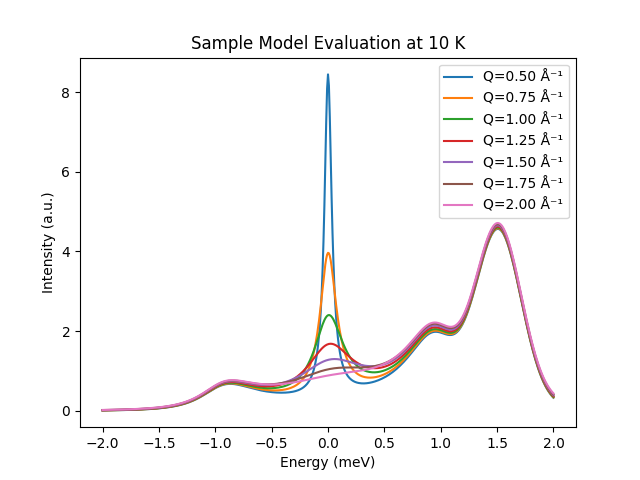

In [3]:
sample_model.generate_component_collections() # This will be done implicitly later, but for now users will need to call it explicitly after making changes
y_list = sample_model.evaluate(energy)

plt.figure()
for i, Q_value in enumerate(Q):
    plt.plot(
        energy,y_list[i],
        label=f"Q={Q_value:.2f} Å⁻¹"
    )
plt.xlabel("Energy (meV)")
plt.ylabel("Intensity (a.u.)")
plt.title("Sample Model Evaluation at 10 K")
plt.legend()
plt.show()

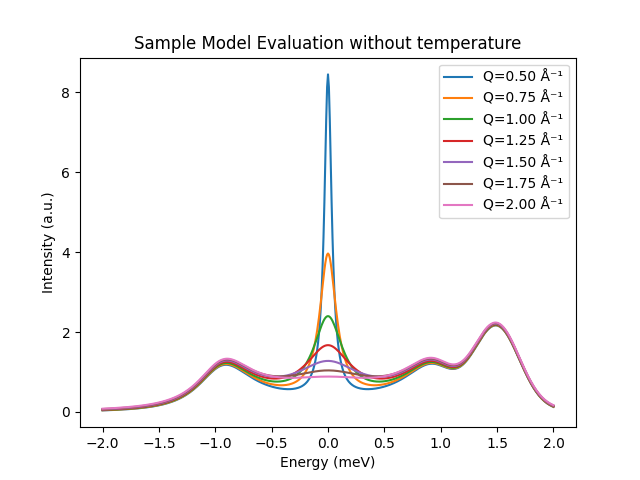

In [4]:
sample_model2=SampleModel()
sample_model2.Q=Q
sample_model2.append_diffusion_model(diffusion_model)
sample_model2.append_component(component_collection)

sample_model2.generate_component_collections()
y_list2 = sample_model2.evaluate(energy)
plt.figure()
for i, Q_value in enumerate(Q):
    plt.plot(
        energy,y_list2[i],
        label=f"Q={Q_value:.2f} Å⁻¹"
    )
plt.xlabel("Energy (meV)")
plt.ylabel("Intensity (a.u.)")
plt.title("Sample Model Evaluation without temperature")
plt.legend()
plt.show()

In [5]:
sample_model._component_collections[2].get_all_variables()


[<Parameter 'Gaussian area': 1.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'Gaussian center': 1.5000 meV, bounds=[-inf:inf]>,
 <Parameter 'Gaussian width': 0.2000 meV, bounds=[1e-10:inf]>,
 <Parameter 'DHO area': 2.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'DHO center': 1.0000 meV, bounds=[1e-10:inf]>,
 <Parameter 'DHO width': 0.3000 meV, bounds=[1e-10:inf]>,
 <Parameter 'Brownian translational diffusion area': 1.0000, bounds=[0.0:inf]>,
 <Parameter 'Brownian translational diffusion center': 0.0000 meV (fixed), bounds=[-inf:inf]>,
 <Parameter 'Brownian translational diffusion width': 0.1580 meV, bounds=[-inf:inf]>]

In [6]:
sample_model.get_fit_parameters()

[<Parameter 'Gaussian area': 1.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'Gaussian center': 1.5000 meV, bounds=[-inf:inf]>,
 <Parameter 'Gaussian width': 0.2000 meV, bounds=[1e-10:inf]>,
 <Parameter 'DHO area': 2.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'DHO center': 1.0000 meV, bounds=[1e-10:inf]>,
 <Parameter 'DHO width': 0.3000 meV, bounds=[1e-10:inf]>,
 <Parameter 'Gaussian area': 1.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'Gaussian center': 1.5000 meV, bounds=[-inf:inf]>,
 <Parameter 'Gaussian width': 0.2000 meV, bounds=[1e-10:inf]>,
 <Parameter 'DHO area': 2.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'DHO center': 1.0000 meV, bounds=[1e-10:inf]>,
 <Parameter 'DHO width': 0.3000 meV, bounds=[1e-10:inf]>,
 <Parameter 'Gaussian area': 1.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'Gaussian center': 1.5000 meV, bounds=[-inf:inf]>,
 <Parameter 'Gaussian width': 0.2000 meV, bounds=[1e-10:inf]>,
 <Parameter 'DHO area': 2.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'DHO center': 1.0000 meV, bound

In [7]:
a.independent

NameError: name 'a' is not defined

In [ ]:
diffusion_model=BrownianTranslationalDiffusion(display_name="DiffusionModel", scale=scale, diffusion_coefficient= diffusion_coefficient, diffusion_unit=diffusion_unit)

collections=diffusion_model.create_component_collections([1.0])
collections[0].get_all_variables()

In [9]:
sample_model.Q=[0.5, 1.0]
sample_model.generate_component_collections()
sample_model.get_all_variables()
sample_model.get_fit_parameters()
# sample_model._component_collections[0]

[<Parameter 'Gaussian area': 1.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'Gaussian center': 1.5000 meV, bounds=[-inf:inf]>,
 <Parameter 'Gaussian width': 0.2000 meV, bounds=[1e-10:inf]>,
 <Parameter 'DHO area': 2.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'DHO center': 1.0000 meV, bounds=[1e-10:inf]>,
 <Parameter 'DHO width': 0.3000 meV, bounds=[1e-10:inf]>,
 <Parameter 'Gaussian area': 1.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'Gaussian center': 1.5000 meV, bounds=[-inf:inf]>,
 <Parameter 'Gaussian width': 0.2000 meV, bounds=[1e-10:inf]>,
 <Parameter 'DHO area': 2.0000 meV, bounds=[0.0:inf]>,
 <Parameter 'DHO center': 1.0000 meV, bounds=[1e-10:inf]>,
 <Parameter 'DHO width': 0.3000 meV, bounds=[1e-10:inf]>,
 <Parameter 'Temperature': 10.0000 K, bounds=[-inf:inf]>,
 <Parameter 'diffusion_coefficient': 2.400e-09 m^2/s, bounds=[-inf:inf]>,
 <Parameter 'scale': 1.0000, bounds=[0.0:inf]>]

In [10]:
print(sample_model)

SampleModel(unique_name=SampleModel_0, unit=meV), Q = [0.5 1. ], components = [Gaussian(unique_name = Gaussian_0, unit = meV,
 area = <Parameter 'Gaussian area': 1.0000 meV, bounds=[0.0:inf]>,
 center = <Parameter 'Gaussian center': 1.5000 meV, bounds=[-inf:inf]>,
 width = <Parameter 'Gaussian width': 0.2000 meV, bounds=[1e-10:inf]>), DampedHarmonicOscillator(display_name = DHO, unit = meV,
 area = <Parameter 'DHO area': 2.0000 meV, bounds=[0.0:inf]>,
 center = <Parameter 'DHO center': 1.0000 meV, bounds=[1e-10:inf]>,
 width = <Parameter 'DHO width': 0.3000 meV, bounds=[1e-10:inf]>)], diffusion_models = [BrownianTranslationalDiffusion(display_name=DiffusionModel, diffusion_coefficient=<Parameter 'diffusion_coefficient': 2.400e-09 m^2/s, bounds=[-inf:inf]>, scale=<Parameter 'scale': 1.0000, bounds=[0.0:inf]>)], temperature = <Parameter 'Temperature': 10.0000 K, bounds=[-inf:inf]>, divide_by_temperature = True
